In [8]:
# %pip install ipympl -q

Note: you may need to restart the kernel to use updated packages.


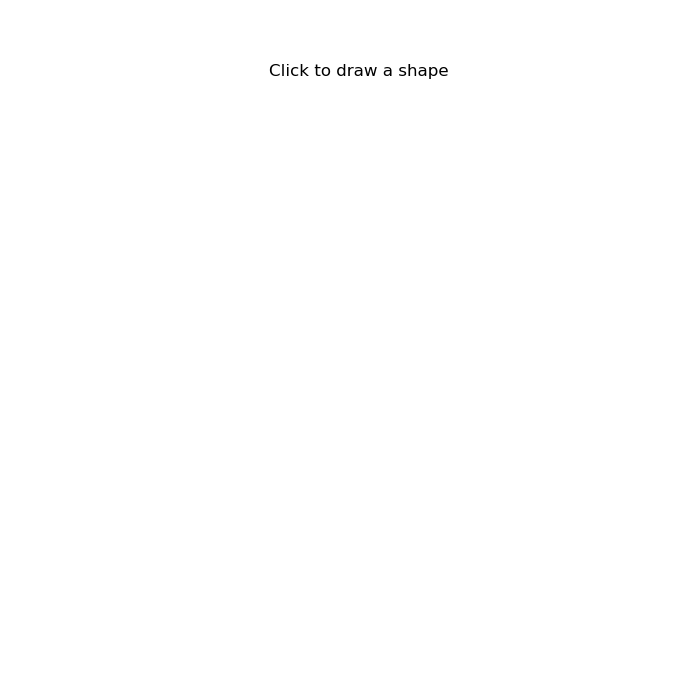

In [2]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import random
import ipywidgets as widgets
from IPython.display import display

# -----------------------------------
# SETUP
# -----------------------------------

points = []

fig, ax = plt.subplots(figsize=(7, 7))

def setup_axes():
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title("Click to draw a shape")
    ax.axis("off")

setup_axes()

# original drawing
line, = ax.plot([], [], marker="o", linewidth=2)


# -----------------------------------
# DRAW BY CLICKING
# -----------------------------------

def onclick(event):

    if event.inaxes != ax:
        return

    points.append([event.xdata, event.ydata])

    p = np.array(points)

    line.set_data(
        p[:, 0],
        p[:, 1]
    )

    fig.canvas.draw_idle()


fig.canvas.mpl_connect(
    "button_press_event",
    onclick
)


# -----------------------------------
# GENERATE COPIES
# -----------------------------------

def generate(_):

    if len(points) < 2:
        return

    p = np.array(points)

    # centre the student's drawing
    p = p - p.mean(axis=0)

    for _ in range(25):

        # random rotation
        angle = random.uniform(0, 2*np.pi)

        R = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])

        # random scale
        scale = random.uniform(0.15, 0.5)

        q = p @ R.T
        q *= scale

        # random position
        q[:, 0] += random.uniform(0.05, 0.95)
        q[:, 1] += random.uniform(0.05, 0.95)

        ax.plot(
            q[:, 0],
            q[:, 1],
            alpha=0.45
        )

    fig.canvas.draw_idle()


# -----------------------------------
# RESET
# -----------------------------------

def reset(_):

    global line

    points.clear()

    ax.clear()
    setup_axes()

    line, = ax.plot(
        [],
        [],
        marker="o",
        linewidth=2
    )

    fig.canvas.draw_idle()


# -----------------------------------
# BUTTONS
# -----------------------------------

generate_button = widgets.Button(
    description="Generate!"
)

reset_button = widgets.Button(
    description="Reset"
)

generate_button.on_click(generate)
reset_button.on_click(reset)

display(
    widgets.HBox([
        generate_button,
        reset_button
    ])
)

plt.show()

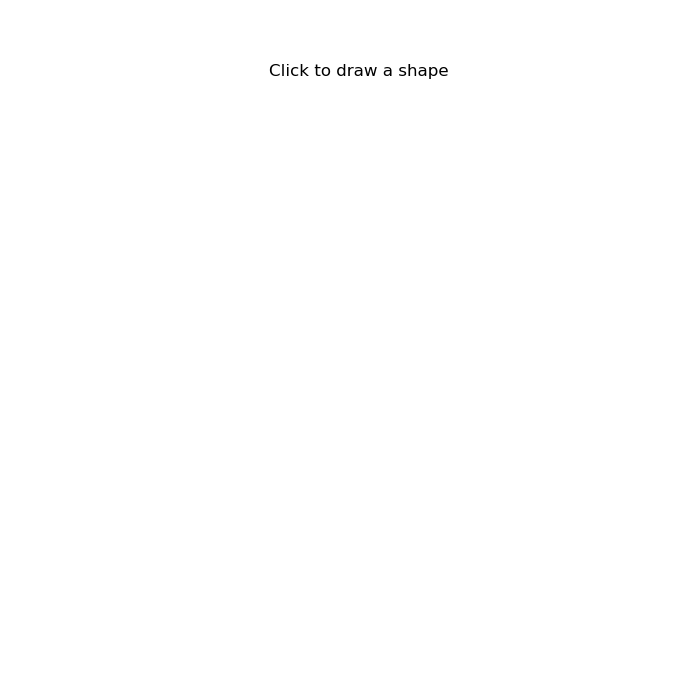

In [5]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import random
import ipywidgets as widgets
from IPython.display import display
from matplotlib.animation import FuncAnimation

# -----------------------------------
# SETUP
# -----------------------------------

points = []
copies = []
animation = None

fig, ax = plt.subplots(figsize=(7, 7))

def setup_axes():
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title("Click to draw a shape")
    ax.axis("off")

setup_axes()

line, = ax.plot([], [], marker="o", linewidth=2)


# -----------------------------------
# DRAW BY CLICKING
# -----------------------------------

def onclick(event):

    if event.inaxes != ax:
        return

    points.append([event.xdata, event.ydata])

    p = np.array(points)

    line.set_data(
        p[:, 0],
        p[:, 1]
    )

    fig.canvas.draw_idle()


fig.canvas.mpl_connect("button_press_event", onclick)


# -----------------------------------
# GENERATE COPIES
# -----------------------------------

def generate(_):

    copies.clear()

    if len(points) < 2:
        return

    p = np.array(points)

    # centre original shape
    p = p - p.mean(axis=0)

    for _ in range(25):

        angle = random.uniform(0, 2*np.pi)
        scale = random.uniform(0.15, 0.5)

        R = np.array([
            [np.cos(angle), -np.sin(angle)],
            [np.sin(angle),  np.cos(angle)]
        ])

        q = scale * (p @ R.T)

        x0 = random.uniform(0.05, 0.95)
        y0 = random.uniform(0.05, 0.95)

        q[:, 0] += x0
        q[:, 1] += y0

        artist, = ax.plot(
            q[:, 0],
            q[:, 1],
            alpha=0.45
        )

        copies.append({
            "artist": artist,
            "base": q.copy(),
            "phase": random.uniform(0, 2*np.pi),
            "speed": random.uniform(0.5, 1.5)
        })

    fig.canvas.draw_idle()


# -----------------------------------
# WIGGLE ANIMATION
# -----------------------------------

def wiggle(_):

    global animation

    if len(copies) == 0:
        return

    def animate(frame):

        t = frame * 0.12

        for c in copies:

            q = c["base"].copy()

            dx = 0.015 * np.sin(
                t * c["speed"] + c["phase"]
            )

            dy = 0.015 * np.cos(
                t * c["speed"] + c["phase"]
            )

            q[:, 0] += dx
            q[:, 1] += dy

            c["artist"].set_data(
                q[:, 0],
                q[:, 1]
            )

        return [c["artist"] for c in copies]

    animation = FuncAnimation(
        fig,
        animate,
        frames=300,
        interval=40,
        blit=False,
        repeat=True
    )

    fig.canvas.draw_idle()


# -----------------------------------
# CHAOS ANIMATION
# -----------------------------------

def chaos(_):

    global animation

    if len(copies) == 0:
        return

    def animate(frame):

        t = frame * 0.08

        for c in copies:

            p = c["base"].copy()

            centre = p.mean(axis=0)
            p = p - centre

            # breathing
            scale = 1 + 0.15*np.sin(
                t*c["speed"] + c["phase"]
            )

            # rotation
            angle = 0.25*np.sin(
                t*0.7 + c["phase"]
            )

            R = np.array([
                [np.cos(angle), -np.sin(angle)],
                [np.sin(angle),  np.cos(angle)]
            ])

            q = scale * (p @ R.T)

            # little drift
            centre[0] += 0.02*np.sin(t + c["phase"])
            centre[1] += 0.02*np.cos(t + c["phase"])

            q += centre

            c["artist"].set_data(
                q[:, 0],
                q[:, 1]
            )

        return [c["artist"] for c in copies]

    animation = FuncAnimation(
        fig,
        animate,
        frames=300,
        interval=40,
        blit=False,
        repeat=True
    )

    fig.canvas.draw_idle()


# -----------------------------------
# STOP
# -----------------------------------

def stop(_):

    global animation

    if animation is not None:
        animation.event_source.stop()


# -----------------------------------
# RESET
# -----------------------------------

def reset(_):

    global line, animation

    if animation is not None:
        animation.event_source.stop()

    animation = None

    points.clear()
    copies.clear()

    ax.clear()
    setup_axes()

    line, = ax.plot(
        [],
        [],
        marker="o",
        linewidth=2
    )

    fig.canvas.draw_idle()


# -----------------------------------
# BUTTONS
# -----------------------------------

generate_button = widgets.Button(description="Generate!")
wiggle_button   = widgets.Button(description="Wiggle!")
chaos_button    = widgets.Button(description="Chaos!")
stop_button     = widgets.Button(description="Stop")
reset_button    = widgets.Button(description="Reset")

generate_button.on_click(generate)
wiggle_button.on_click(wiggle)
chaos_button.on_click(chaos)
stop_button.on_click(stop)
reset_button.on_click(reset)

display(
    widgets.HBox([
        generate_button,
        wiggle_button,
        chaos_button,
        stop_button,
        reset_button
    ])
)

plt.show()